In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

#DATA COLLECTION & EXPLORATION

# Load data
Tech_employee_salary = pd.read_csv('Tech_employee_salary.csv')

In [2]:
#Explore data
Tech_employee_salary.head()

,employee_id,years_experience,gender,education_level,job_title,location,work_mode,primary_language,performance_rating,projects_completed,team_size,overtime_hours_month,certifications_count,github_contributions,birth_month,bonus_percentage,stock_options,remote_work_days,satisfaction_score,salary_category
0,EMP_0001,11,male,PhD,Full Stack Developer,"Chicago, IL",On-site,C++,3.2,19,9,15,6,370,March,NaN,Yes,2.0,3.7,Medium
1,EMP_0002,20,male,Bachelor,Frontend Developer,Remote,Hybrid,C++,4.1,30,13,7,8,523,March,13.0,Yes,3.0,3.1,Medium
2,EMP_0003,21,male,Bachelor,Engineering Manager,"Toronto, CA",Remote,Rust,3.9,32,10,1,9,555,September,10.0,No,3.0,4.9,High
3,EMP_0004,7,female,PhD,Data Scientist,"Los Angeles, CA",Remote,TypeScript,3.3,17,4,0,4,253,February,24.0,No,1.0,NaN,Medium
4,EMP_0005,10,female,Bachelor,Engineering Manager,"London, UK",Remote,Python,3.6,15,3,0,4,255,November,15.0,Yes,5.0,2.8,High


In [3]:
Tech_employee_salary.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           5000 non-null   str    
 1   years_experience      5000 non-null   int64  
 2   gender                5000 non-null   str    
 3   education_level       5000 non-null   str    
 4   job_title             5000 non-null   str    
 5   location              5000 non-null   str    
 6   work_mode             5000 non-null   str    
 7   primary_language      5000 non-null   str    
 8   performance_rating    5000 non-null   float64
 9   projects_completed    5000 non-null   int64  
 10  team_size             5000 non-null   int64  
 11  overtime_hours_month  5000 non-null   int64  
 12  certifications_count  5000 non-null   int64  
 13  github_contributions  5000 non-null   int64  
 14  birth_month           5000 non-null   str    
 15  bonus_percentage      4597 non-n

In [4]:
Tech_employee_salary.describe()

,years_experience,performance_rating,projects_completed,team_size,overtime_hours_month,certifications_count,github_contributions,bonus_percentage,remote_work_days,satisfaction_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4597.000000,4911.000000,4746.000000
mean,11.485800,3.166120,21.442600,7.950600,7.305000,5.496400,387.884000,14.986948,2.500509,2.982280
std,6.362758,0.598665,7.062257,4.305191,7.946761,2.548978,189.588911,6.026978,1.709072,1.152124
min,0.000000,1.000000,4.000000,1.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000
25%,7.000000,2.800000,16.000000,4.000000,2.000000,4.000000,253.000000,10.000000,1.000000,2.000000
50%,11.000000,3.200000,21.000000,8.000000,5.000000,5.000000,371.000000,15.000000,2.000000,3.000000
75%,15.000000,3.600000,26.000000,12.000000,10.000000,7.000000,497.000000,20.000000,4.000000,4.000000
max,30.000000,5.000000,47.000000,15.000000,66.000000,16.000000,1549.000000,25.000000,5.000000,5.000000


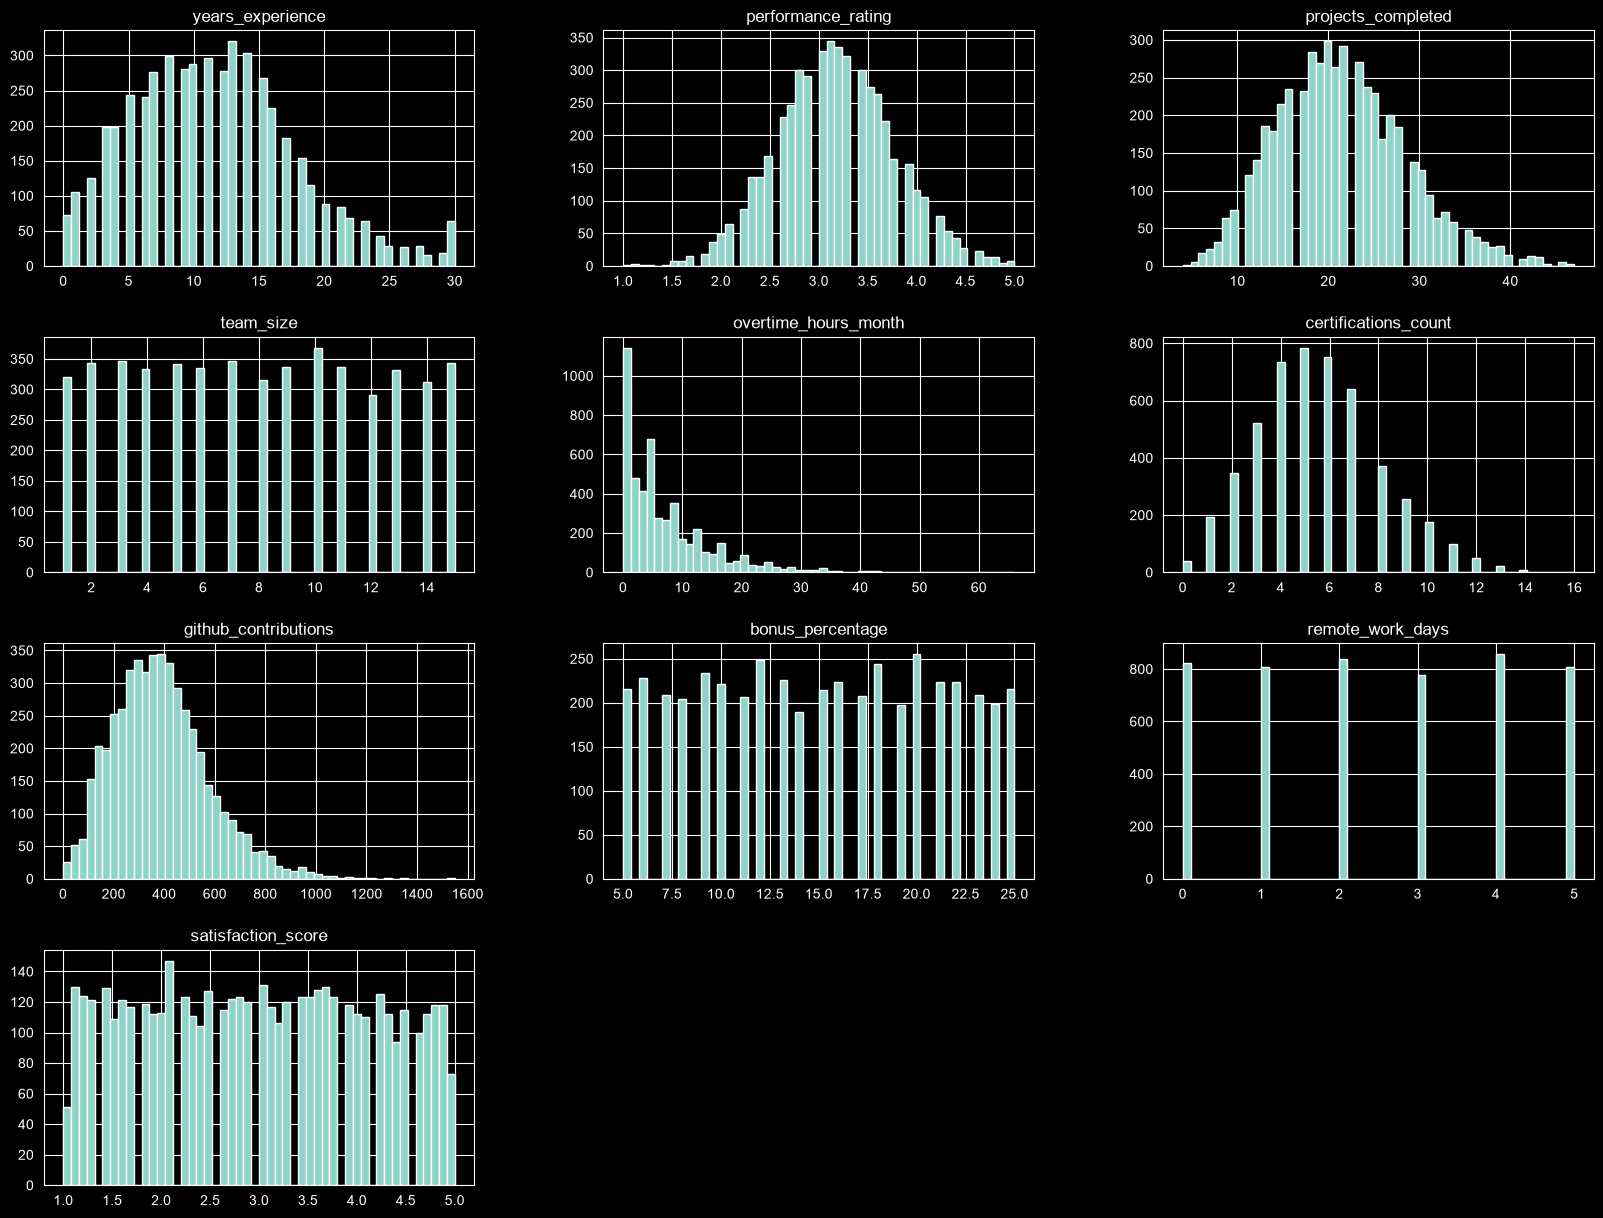

In [5]:
Tech_employee_salary.hist(bins=50, figsize=(20,15))
plt.show()
sns.set(rc={'figure.figsize':(5,5)})

In [7]:
print(f'years_experience is capped at value {Tech_employee_salary["years_experience"].max()}')
print(f'projects_completed is capped at value {Tech_employee_salary['projects_completed'].max()}')
print(f'overtime_hours_month is capped at value {Tech_employee_salary['overtime_hours_month'].max()}')

years_experience is capped at value 30
projects_completed is capped at value 47
overtime_hours_month is capped at value 66


In [8]:
for col in Tech_employee_salary.select_dtypes(include='object').columns: 
    print(f"\n--- {col} ---") 
    print(Tech_employee_salary[col].value_counts())


--- employee_id ---
employee_id
EMP_0001    1
EMP_0002    1
EMP_0003    1
EMP_0004    1
EMP_0005    1
           ..
EMP_4996    1
EMP_4997    1
EMP_4998    1
EMP_4999    1
EMP_5000    1
Name: count, Length: 5000, dtype: int64

--- gender ---
gender
male      2526
female    2474
Name: count, dtype: int64

--- education_level ---
education_level
Bachelor       2432
Master         1546
High School     545
PhD             477
Name: count, dtype: int64

--- job_title ---
job_title
UI/UX Designer          350
Backend Developer       328
Tech Lead               327
Product Manager         324
ML Engineer             316
Full Stack Developer    314
Frontend Developer      314
QA Engineer             310
DevOps Engineer         309
Data Scientist          307
Software Engineer       307
Solutions Architect     307
Security Engineer       305
Engineering Manager     302
Data Analyst            295
Cloud Architect         285
Name: count, dtype: int64

--- location ---
location
New York, NY     

/var/folders/9d/0nsc67zs2kj64c6r_f1xvnmw0000gn/T/ipykernel_20210/4171807362.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in Tech_employee_salary.select_dtypes(include='object').columns:


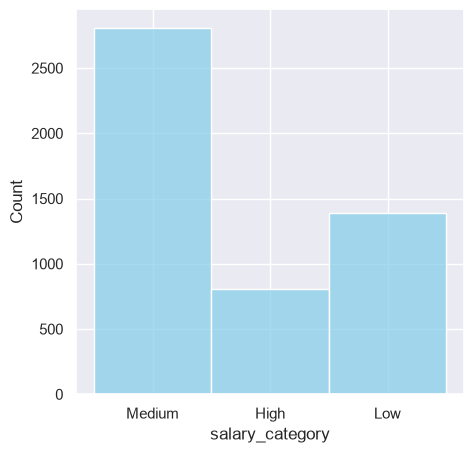

In [9]:
sns.histplot(Tech_employee_salary['salary_category'],color='skyblue')
plt.show()

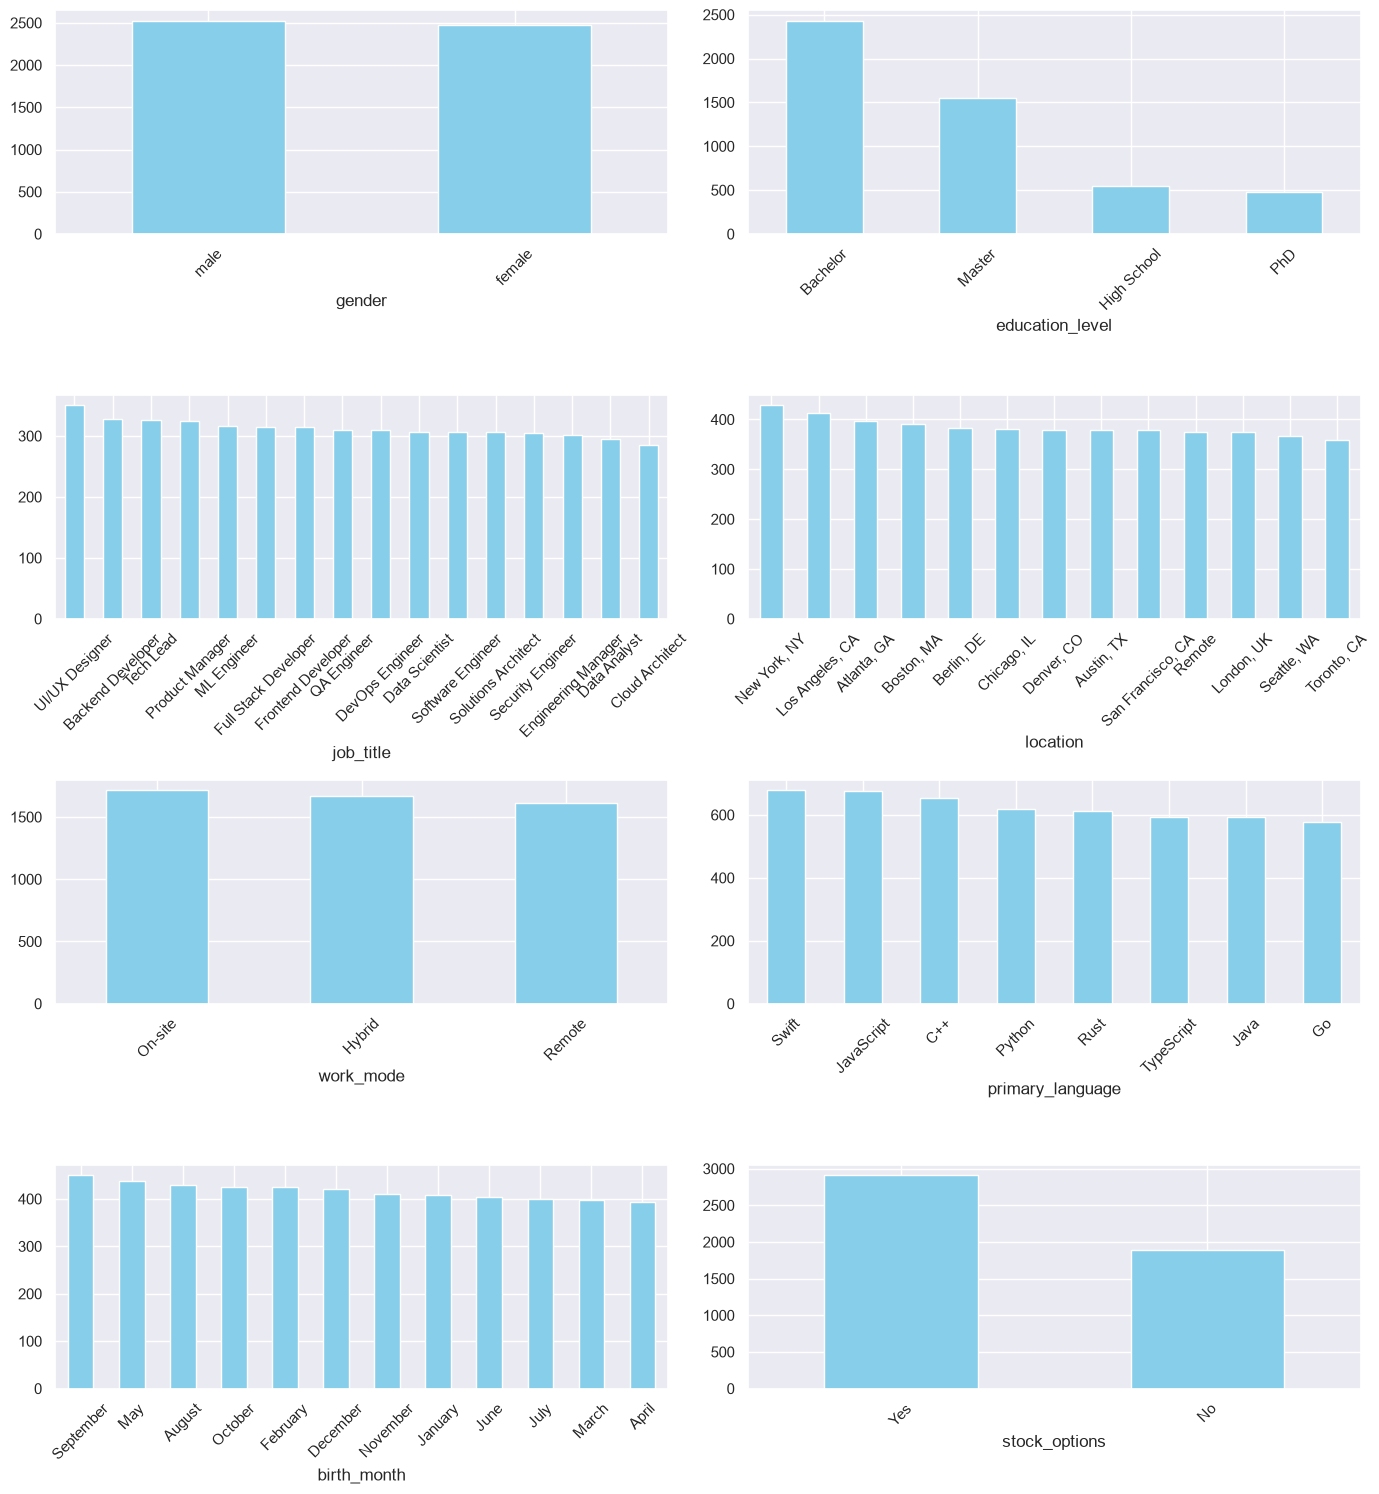

In [10]:
categorical_cols = ['gender', 'education_level', 'job_title', 'location', 'work_mode', 
                   'primary_language', 'birth_month', 'stock_options']

plt.figure(figsize=(14, 18))

for i in range(len(categorical_cols)):
    plt.subplot(5, 2, i + 1)
    Tech_employee_salary[categorical_cols[i]].value_counts().plot(kind='bar', color='skyblue')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# DATA PREPROCESSING

#Split Data to Train & Testing set
X = Tech_employee_salary.drop('salary_category', axis = 1)
y = Tech_employee_salary['salary_category']

print ('Shape of original dataset, train:', Tech_employee_salary.shape)
print ('X: shape=', X.shape, 'type=', type(X))
print ('y: shape=', y.shape, 'type=', type(y))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

print ('full set shape=', X.shape)
print ('train shape=', X_train.shape)
print ('test shape=', X_test.shape)

Shape of original dataset, train: (5000, 20)
X: shape= (5000, 19) type= <class 'pandas.DataFrame'>
y: shape= (5000,) type= <class 'pandas.Series'>
full set shape= (5000, 19)
train shape= (4000, 19)
test shape= (1000, 19)


In [12]:
#Split the input matrix into numerical and categorical sets
all_categorical_cols = ['employee_id','gender', 'education_level', 'job_title', 'location', 'work_mode', 
                   'primary_language', 'birth_month', 'stock_options']

X_train_num = X_train.drop(all_categorical_cols, axis=1)  # Drop categorical columns to get numerical
X_train_cat = X_train[all_categorical_cols] 

X_train_cat = X_train_cat.drop('employee_id', axis=1) 

print('X_train_num shape:', X_train_num.shape)
print('X_train_cat shape:', X_train_cat.shape)

X_train_num shape: (4000, 10)
X_train_cat shape: (4000, 8)


In [13]:
# Handling missing values
print('Number of missing values for all columns:')
X_train_num.isnull().sum()

from sklearn.impute import SimpleImputer   

imputer = SimpleImputer(strategy = 'median')
imputer.fit(X_train_num)                              # compute the median     
X_train_num_tr = imputer.transform(X_train_num)       # fill up missing values with median value for the feature

print('Type of X_train_num:', type(X_train_num))
print('Type of X_train_num_tr:', type(X_train_num_tr))

print('Number of missing values for all columns:')
X_train_num_tr_pd = pd.DataFrame(X_train_num_tr, columns = X_train_num.columns)
X_train_num_tr_pd.isnull().sum()

Number of missing values for all columns:
Type of X_train_num: <class 'pandas.DataFrame'>
Type of X_train_num_tr: <class 'numpy.ndarray'>
Number of missing values for all columns:


years_experience        0
performance_rating      0
projects_completed      0
team_size               0
overtime_hours_month    0
certifications_count    0
github_contributions    0
bonus_percentage        0
remote_work_days        0
satisfaction_score      0
dtype: int64

In [14]:
#preprocessing numerical data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(copy = False)
scaler.fit(X_train_num_tr)       
X_train_num_tr = scaler.transform(X_train_num_tr)

print('>>> Mean of all columns:\n', X_train_num_tr.mean(axis=0))
print('\n>>> Std of all columns:\n', X_train_num_tr.std(axis=0))

>>> Mean of all columns:
 [ 8.88178420e-18 -3.69482223e-16 -5.41788836e-17 -5.68434189e-17
 -3.68594044e-17  1.77635684e-17 -9.23705556e-17  1.42108547e-16
  8.70414851e-17 -7.54951657e-17]

>>> Std of all columns:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [15]:
#preprocessing categorical data
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_cat_tr = ohe.fit_transform(X_train_cat)

feature_names = ohe.get_feature_names_out(X_train_cat.columns)

print('Shape of X_train_cat_tr:', X_train_cat_tr.shape)
print('Feature names:', feature_names)

Shape of X_train_cat_tr: (4000, 61)
Feature names: ['gender_female' 'gender_male' 'education_level_Bachelor'
 'education_level_High School' 'education_level_Master'
 'education_level_PhD' 'job_title_Backend Developer'
 'job_title_Cloud Architect' 'job_title_Data Analyst'
 'job_title_Data Scientist' 'job_title_DevOps Engineer'
 'job_title_Engineering Manager' 'job_title_Frontend Developer'
 'job_title_Full Stack Developer' 'job_title_ML Engineer'
 'job_title_Product Manager' 'job_title_QA Engineer'
 'job_title_Security Engineer' 'job_title_Software Engineer'
 'job_title_Solutions Architect' 'job_title_Tech Lead'
 'job_title_UI/UX Designer' 'location_Atlanta, GA' 'location_Austin, TX'
 'location_Berlin, DE' 'location_Boston, MA' 'location_Chicago, IL'
 'location_Denver, CO' 'location_London, UK' 'location_Los Angeles, CA'
 'location_New York, NY' 'location_Remote' 'location_San Francisco, CA'
 'location_Seattle, WA' 'location_Toronto, CA' 'work_mode_Hybrid'
 'work_mode_On-site' 'work_mod

In [16]:
#Finalizing training set
X_train_tr = np.hstack([X_train_num_tr, X_train_cat_tr])
y_train = y_train.values;  #convert to numpy array

print('X_train_tr shape:', X_train_tr.shape)
print('y_train shape:', y_train.shape)

X_train_tr shape: (4000, 71)
y_train shape: (4000,)


In [17]:
from sklearn.preprocessing import LabelEncoder

labelE = LabelEncoder();
y_train_encoded = labelE.fit_transform(y_train)

In [18]:
#Training SGDClassifier 
#Train a binary model
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state = 42, max_iter = 5, tol = None)
sgd_clf.fit(X_train_tr, y_train_encoded)

y_pred_sgd = sgd_clf.predict(X_train_tr)

def peek_results(actual, predicted, num = 20):
    print('actual |  Predicted')
    print('------------------')
    for i in range(num):
        sel = np.random.randint(0, len(y_train))
        print(actual[sel], ' |', predicted[sel])
        
peek_results(y_train_encoded, y_pred_sgd)

actual |  Predicted
------------------
0  | 0
2  | 2
1  | 1
0  | 0
1  | 2
1  | 2
2  | 2
0  | 0
2  | 2
0  | 0
1  | 2
2  | 1
0  | 0
2  | 2
2  | 2
2  | 2
2  | 1
0  | 2
2  | 2
0  | 0


In [19]:
#Performance Measure: Accuracy

from sklearn.metrics import accuracy_score

train_acc_sgd = accuracy_score(y_train_encoded, y_pred_sgd)

print("Training Accuracy: {:.4f}".format(train_acc_sgd))

Training Accuracy: 0.7338


In [20]:
from sklearn.model_selection import cross_val_score

k_scores_sgd = cross_val_score(sgd_clf, X_train_tr, y_train_encoded, cv = 3, scoring = 'accuracy')
k_scores_sgd

array([0.70464768, 0.70817704, 0.7711928 ])

In [21]:
from sklearn.metrics import accuracy_score

y_train_pred_sgd = sgd_clf.predict(X_train_tr)  # make sure sgd_clf has been trained
print('Accuracy using prediction values:', accuracy_score(y_train_encoded, y_train_pred_sgd))

y_train_allfalse_sgd = np.zeros(len(y_train_encoded), dtype=bool)
print('Accuracy using prediction values:', accuracy_score(y_train_encoded, y_train_allfalse_sgd))

Accuracy using prediction values: 0.73375
Accuracy using prediction values: 0.156


In [22]:
#Performance Measure: Confusion Matrix

from sklearn.model_selection import cross_val_predict

y_pred_cv_sgd = cross_val_predict (sgd_clf, X_train_tr, y_train_encoded, cv=3)

In [23]:
peek_results(y_train_encoded, y_pred_cv_sgd)

actual |  Predicted
------------------
2  | 2
2  | 2
2  | 2
1  | 1
2  | 0
2  | 2
0  | 0
2  | 2
2  | 2
1  | 1
2  | 2
2  | 2
2  | 2
2  | 2
2  | 2
2  | 2
2  | 2
0  | 2
0  | 2
2  | 2


In [24]:
from sklearn.metrics import confusion_matrix
cm_sgd = confusion_matrix(y_train_encoded, y_pred_cv_sgd)
print(cm_sgd)

[[ 321    0  303]
 [   3  853  262]
 [ 221  299 1738]]


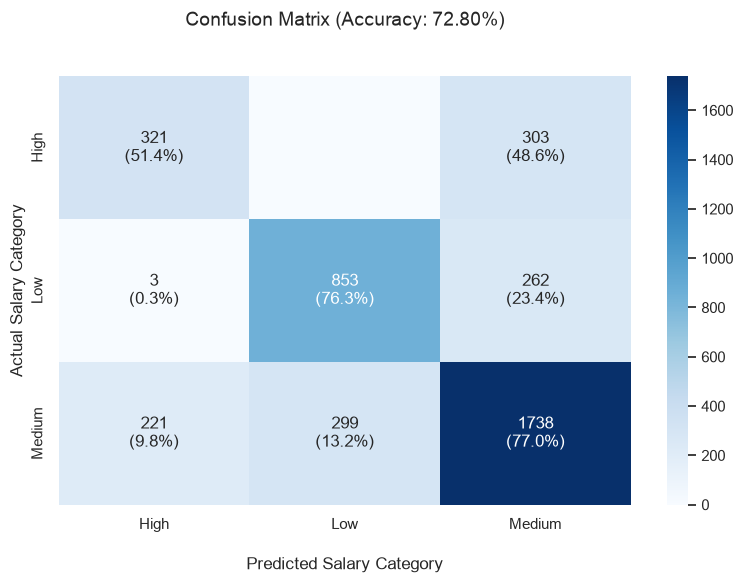

In [25]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# For multiclass confusion matrix
class_names = labelE.classes_  # ['High', 'Low', 'Medium'] or similar

# Calculate percentages
cm_percent = cm_sgd.astype('float') / cm_sgd.sum(axis=1)[:, np.newaxis] * 100

# Create annotation labels
annot_labels = np.empty_like(cm_sgd).astype(str)
n_rows, n_cols = cm_sgd.shape

for i in range(n_rows):
    for j in range(n_cols):
        count = cm_sgd[i, j]
        percentage = cm_percent[i, j]
        if count == 0:
            annot_labels[i, j] = ''
        else:
            annot_labels[i, j] = f'{count}\n({percentage:.1f}%)'

# Create the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_sgd, annot=annot_labels, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

ax.set_title('Confusion Matrix - Multiclass Classification\n\n', fontsize=14)
ax.set_xlabel('\nPredicted Salary Category', fontsize=12)
ax.set_ylabel('Actual Salary Category', fontsize=12)

# Add overall accuracy in the title
accuracy = np.trace(cm_sgd) / np.sum(cm_sgd)
ax.set_title(f'Confusion Matrix (Accuracy: {accuracy:.2%})\n\n', fontsize=14)

plt.tight_layout()
plt.show()

In [26]:
#Performance Measure: Precision, Recall and F1 Score

from sklearn.metrics import precision_score, recall_score, f1_score

print('precision = {:.4f}'.format(precision_score(y_train_encoded, y_pred_sgd, average='macro')))
print('recall    = {:.4f}'.format(recall_score(y_train_encoded, y_pred_cv_sgd, average='macro')))
print('f1 score  = {:.4f}'.format(f1_score(y_train_encoded, y_pred_cv_sgd, average='macro')))

precision = 0.7653
recall    = 0.6824
f1 score  = 0.6876


In [27]:
#Performance Measure: Precision Recall Curve
def peek_score(actual, scores, num=20):
    print('actual | score')
    print('-----------------')
    for i in range(num):
        sel = np.random.randint(0,len(y_train))
        print(actual[sel], ' |', scores[sel])

y_scores_sgd = sgd_clf.decision_function(X_train_tr)

peek_score(y_train_encoded, y_scores_sgd)

actual | score
-----------------
1  | [-20.2730172   -7.41305659  13.40026763]
2  | [-33.78548618 -11.16556683   2.47166118]
2  | [ -2.19744589 -26.31647354  -1.19431979]
2  | [-29.42400518 -12.09141522   2.67194004]
2  | [-10.0228208  -29.1688944    2.12931424]
1  | [-36.98416883  12.66933531   2.3132977 ]
0  | [ -3.06036303 -28.55067899  -4.06294876]
2  | [-16.03713296 -10.49375669   4.95170419]
0  | [ -3.23042828 -36.18120862  -5.98326321]
2  | [-24.09484507 -18.83891887   0.58629777]
2  | [-13.12900167 -14.99516668  -0.31636888]
1  | [-33.56317215   0.87322526   6.29284436]
1  | [-22.72579302  -2.87384159  -4.47173981]
2  | [ -7.69953023 -16.91697314  -0.20987023]
2  | [-23.11733931 -11.66216223   5.12884346]
2  | [-10.56059599 -35.61739896   0.8756019 ]
2  | [ -7.62273451 -16.42295885   6.54395314]
1  | [-36.09813442   1.29478742   8.26392892]
2  | [-13.46621363 -12.71716191  -0.21376317]
1  | [-36.83330995   1.02707022  16.41159963]


In [28]:
y_scores_cv_sgd = cross_val_predict (sgd_clf, X_train_tr, y_train_encoded, cv = 3, method = "decision_function")
y_scores_cv_sgd

array([[-16.87437243, -23.34279829,  -2.70179118],
       [-34.53731472,  -4.39920174, -12.84081911],
       [ -6.34421908, -21.06833364, -22.46576922],
       ...,
       [-49.18381451,  20.56348411,  -2.71781195],
       [ 32.20851331, -78.10201074,   9.96092023],
       [  7.26655394, -63.458605  ,  22.50772752]], shape=(4000, 3))

In [29]:
#Training using RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(n_estimators = 10, random_state = 42)
forest_clf.fit(X_train_tr, y_train_encoded)

y_pred_forest = forest_clf.predict(X_train_tr)

def peek_results(actual, predicted, num = 20):
    print('actual |  Predicted')
    print('------------------')
    for i in range(num):
        sel = np.random.randint(0, len(y_train))
        print(actual[sel], ' |', predicted[sel])
        
peek_results(y_train_encoded, y_pred_forest)

actual |  Predicted
------------------
0  | 0
0  | 0
1  | 1
1  | 1
1  | 1
2  | 2
2  | 2
1  | 1
2  | 2
0  | 0
1  | 1
2  | 2
0  | 0
1  | 1
2  | 2
2  | 2
2  | 2
2  | 2
1  | 1
0  | 0


In [30]:
#Performance Measure: Accuracy

train_acc_forest = accuracy_score(y_train_encoded, y_pred_forest)

print ("Training Accuracy: {:.4f}".format(train_acc_forest))

Training Accuracy: 0.9915


In [31]:
k_scores_forest = cross_val_score(forest_clf, X_train_tr, y_train_encoded, cv = 3, scoring='accuracy')
k_scores_forest

array([0.72338831, 0.74343586, 0.73368342])

In [32]:
y_train_pred_forest = forest_clf.predict(X_train_tr)
print("Accuracy using prediction values: ", accuracy_score(y_train_encoded, y_train_pred_forest))

y_train_allfalse_forest = np.zeros(len(y_train_encoded), dtype = bool)
print("Accuracy using prediction values: ", accuracy_score(y_train_encoded, y_train_allfalse_forest))

Accuracy using prediction values:  0.9915
Accuracy using prediction values:  0.156


In [33]:
#Performance Measure: Confusion Matrix

y_pred_cv_forest = cross_val_predict (forest_clf, X_train_tr, y_train_encoded, cv = 3)
peek_results(y_train_encoded, y_pred_cv_forest)

actual |  Predicted
------------------
2  | 0
2  | 2
2  | 2
2  | 2
2  | 0
2  | 2
2  | 1
2  | 2
1  | 2
1  | 1
1  | 1
1  | 1
1  | 1
1  | 1
0  | 0
2  | 2
2  | 2
2  | 2
2  | 2
2  | 2


In [34]:
cm_forest = confusion_matrix(y_train_encoded, y_pred_cv_forest)
print(cm_forest)

[[ 332    1  291]
 [   2  791  325]
 [ 149  298 1811]]


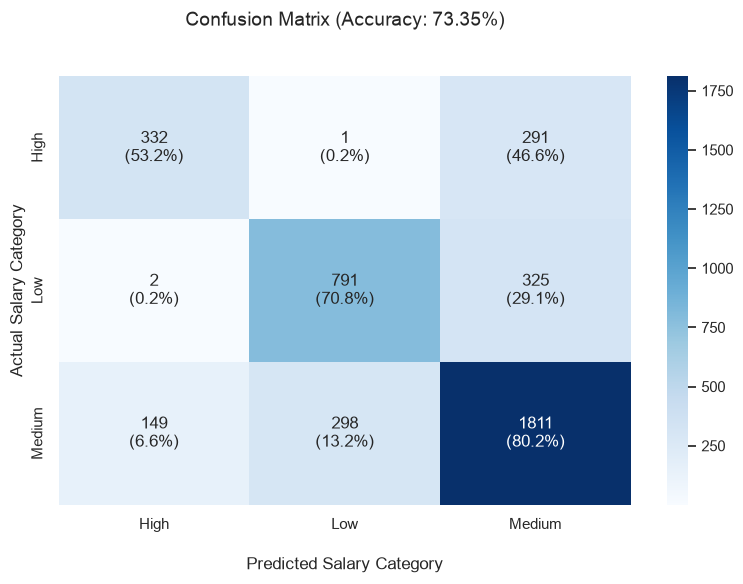

In [35]:
# For multiclass confusion matrix


# Calculate percentages
cm_percent_forest = cm_forest.astype('float') / cm_forest.sum(axis=1)[:, np.newaxis] * 100

# Create annotation labels
annot_labels = np.empty_like(cm_forest).astype(str)
n_rows, n_cols = cm_forest.shape

for i in range(n_rows):
    for j in range(n_cols):
        count = cm_forest[i, j]
        percentage = cm_percent_forest[i, j]
        if count == 0:
            annot_labels[i, j] = ''
        else:
            annot_labels[i, j] = f'{count}\n({percentage:.1f}%)'

# Create the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_forest, annot=annot_labels, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

ax.set_title('Confusion Matrix - Multiclass Classification\n\n', fontsize=14)
ax.set_xlabel('\nPredicted Salary Category', fontsize=12)
ax.set_ylabel('Actual Salary Category', fontsize=12)

# Add overall accuracy in the title
accuracy = np.trace(cm_forest) / np.sum(cm_forest)
ax.set_title(f'Confusion Matrix (Accuracy: {accuracy:.2%})\n\n', fontsize=14)

plt.tight_layout()
plt.show()

In [36]:
#Performance Measure: Precision, Recall and F1 Score

print('Precision = {:.4f}'.format(precision_score(y_train_encoded, y_pred_cv_forest, average = 'macro')))
print('Recall    = {:.4f}'.format(recall_score(y_train_encoded, y_pred_cv_forest, average = 'macro')))
print('F1 Score  = {:.4f}'.format(f1_score(y_train_encoded, y_pred_cv_forest, average = 'macro')))

Precision = 0.7197
Recall    = 0.6805
F1 Score  = 0.6965


In [37]:
# Performance Measure: Precision-Recall Curve
def peek_scores(actual, scores, num = 20):
    print('actual |  score')
    print('------------------')
    for i in range(num):
        sel = np.random.randint(0, len(y_train))
        print(actual[sel], ' |', scores[sel])

y_scores_forest = sgd_clf.decision_function(X_train_tr)  # retrieve classification scores
peek_scores(y_train_encoded, y_scores_forest)

actual |  score
------------------
2  | [-17.72245226  -4.67885849  -2.55446711]
0  | [ -4.16360413 -43.58552677  -2.28622621]
2  | [-19.17421195 -10.42915081   1.69381545]
2  | [-18.80196537 -28.59164326  12.05897068]
1  | [-42.92520381  13.01062267   2.73869756]
0  | [ -4.32166878 -24.94678809  -5.51442596]
2  | [-17.29059504 -14.21282461   1.87866843]
1  | [-37.66682605   9.05235862   3.07865897]
2  | [ -6.29595023 -32.5697245   -3.2695437 ]
2  | [-16.32338125 -17.75787312   3.30195253]
2  | [-17.29059504 -14.21282461   1.87866843]
1  | [-54.51443468  23.55421214  -0.13769014]
2  | [-22.2347014  -14.31295784   1.39429534]
1  | [-35.5653778    3.99159449  13.75406994]
1  | [-41.47578342  14.38125586   7.00229254]
1  | [-55.81305928  23.18692145   2.95373649]
1  | [-40.52899848   1.24567484  11.29164122]
1  | [-41.8970288   27.99260441   7.62564958]
2  | [-24.93644996 -12.86025256  11.17809822]
2  | [-28.352974   -21.25741504   7.4843172 ]


In [38]:
y_scores_cv_forest = cross_val_predict(forest_clf, X_train_tr, y_train_encoded, cv = 3, method ="predict_proba")
y_scores_cv_forest

array([[0.2, 0. , 0.8],
       [0.2, 0. , 0.8],
       [0. , 0.1, 0.9],
       ...,
       [0. , 0.7, 0.3],
       [0.7, 0. , 0.3],
       [0.2, 0.1, 0.7]], shape=(4000, 3))

In [39]:
#Training using Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(random_state = 42, max_iter = 1000)
lr_clf.fit(X_train_tr, y_train_encoded)

y_pred_lr = lr_clf.predict(X_train_tr)

def peek_results(actual, predicted, num = 20):
    print('actual |  Predicted')
    print('------------------')
    for i in range(num):
        sel = np.random.randint(0, len(y_train))
        print(actual[sel], ' |', predicted[sel])
        
peek_results(y_train_encoded, y_pred_lr)

actual |  Predicted
------------------
2  | 2
2  | 2
1  | 1
2  | 2
2  | 2
1  | 1
2  | 2
2  | 2
1  | 1
1  | 2
2  | 2
2  | 2
0  | 2
2  | 2
1  | 2
2  | 2
2  | 2
0  | 0
1  | 1
1  | 1


In [40]:
#Performance Measure: Accuracy

train_acc_lr = accuracy_score(y_train_encoded, y_pred_lr)

print("Training Accuracy: {:.4f}".format(train_acc_lr))

Training Accuracy: 0.8645


In [41]:

k_scores_lr = cross_val_score(lr_clf, X_train_tr, y_train_encoded, cv = 3, scoring = 'accuracy')
k_scores_lr

array([0.85007496, 0.83420855, 0.84846212])

In [42]:
y_train_pred_lr = lr_clf.predict(X_train_tr)
print("Accuracy using prediction values: ", accuracy_score(y_train_encoded, y_train_pred_lr))

y_train_allfalse_lr = np.zeros(len(y_train_encoded), dtype = bool)
print("Accuracy using prediction values: ", accuracy_score(y_train_encoded, y_train_allfalse_lr)) 

Accuracy using prediction values:  0.8645
Accuracy using prediction values:  0.156


In [43]:
#Performance Measure: Confusion Matrix

y_pred_cv_lr = cross_val_predict(lr_clf, X_train_tr, y_train_encoded, cv = 3)
peek_results(y_train_encoded, y_pred_cv_lr)

actual |  Predicted
------------------
0  | 2
2  | 2
2  | 2
1  | 1
2  | 1
2  | 2
2  | 0
1  | 1
0  | 0
2  | 2
2  | 2
0  | 0
1  | 1
0  | 0
0  | 0
2  | 2
2  | 2
2  | 0
2  | 2
2  | 2


In [44]:
cm_lr = confusion_matrix(y_train_encoded, y_pred_cv_lr)
print(cm_lr)

[[ 454    0  170]
 [   0  918  200]
 [  97  156 2005]]


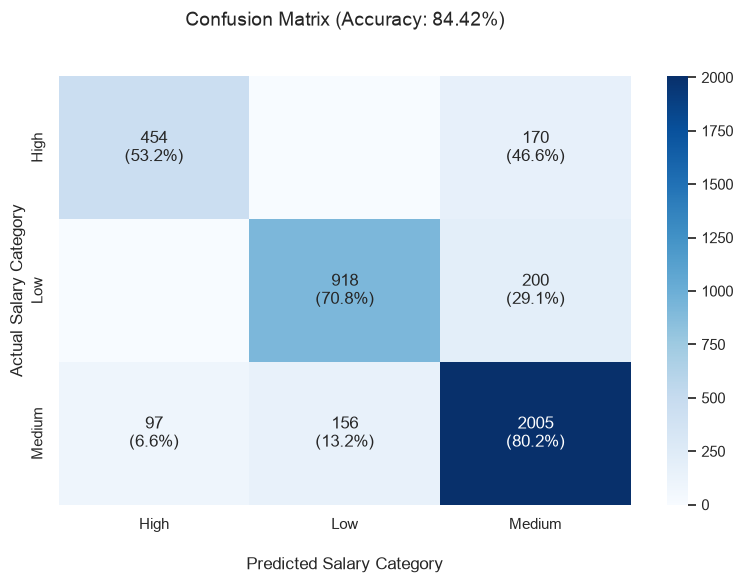

In [45]:
# Calculate percentages
cm_percent_lr = cm_lr.astype('float') / cm_lr.sum(axis=1)[:, np.newaxis] * 100

# Create annotation labels
annot_labels = np.empty_like(cm_lr).astype(str)
n_rows, n_cols = cm_lr.shape

for i in range(n_rows):
    for j in range(n_cols):
        count = cm_lr[i, j]
        percentage = cm_percent_forest[i, j]
        if count == 0:
            annot_labels[i, j] = ''
        else:
            annot_labels[i, j] = f'{count}\n({percentage:.1f}%)'

# Create the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_lr, annot=annot_labels, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

ax.set_title('Confusion Matrix - Multiclass Classification\n\n', fontsize=14)
ax.set_xlabel('\nPredicted Salary Category', fontsize=12)
ax.set_ylabel('Actual Salary Category', fontsize=12)

# Add overall accuracy in the title
accuracy = np.trace(cm_lr) / np.sum(cm_lr)
ax.set_title(f'Confusion Matrix (Accuracy: {accuracy:.2%})\n\n', fontsize=14)

plt.tight_layout()
plt.show()

In [46]:
#Performance Measure: Precision, Recall, and F1 Score
print('Precision = {:.4f}'.format(precision_score(y_train_encoded, y_pred_cv_lr, average = 'macro')))
print('Recall    = {:.4f}'.format(recall_score (y_train_encoded, y_pred_cv_lr, average = 'macro')))
print('F1 Score  = {:.4f}'.format(f1_score(y_train_encoded, y_pred_cv_lr, average = 'macro')))

Precision = 0.8410
Recall    = 0.8122
F1 Score  = 0.8253


In [47]:
#Performance Measure: Precision-Recall Curve

def peek_scores(actual, scores, num = 20):
    print('actual |  score')
    print('------------------')
    for i in range(num):
        sel = np.random.randint(0, len(y_train))
        print(actual[sel], ' |', scores[sel])

y_scores_lr = lr_clf.decision_function(X_train_tr) 

peek_scores(y_train_encoded, y_scores_lr)

actual |  score
------------------
2  | [-7.21879578  4.48000831  2.73878747]
2  | [-5.79521136  3.1792905   2.61592086]
1  | [-14.43066786  11.90881056   2.5218573 ]
0  | [ 5.24147443 -8.46598584  3.22451141]
0  | [ 1.39981835 -4.24552662  2.84570827]
2  | [-4.12656466  1.17906895  2.94749571]
1  | [-5.51013575  3.14332834  2.36680741]
2  | [-3.41984423  1.07065948  2.34918475]
2  | [-3.94249415  0.94198685  3.0005073 ]
1  | [-7.42117274  5.19795258  2.22322016]
1  | [-7.18852521  5.20765674  1.98086847]
1  | [-6.52276718  4.14168264  2.38108454]
2  | [-0.11192116 -2.35192915  2.46385032]
2  | [-3.99806587  1.62208124  2.37598463]
1  | [-6.82596608  4.40564519  2.42032089]
1  | [-4.7568392   2.66199205  2.09484715]
2  | [-4.12080136  1.61452461  2.50627675]
2  | [ 0.81753888 -3.51394058  2.6964017 ]
1  | [-5.68222773  2.86011959  2.82210813]
0  | [ 2.9760549  -6.79107943  3.81502453]


In [48]:
y_scores_cv_lr = cross_val_predict (lr_clf, X_train_tr, y_train_encoded, cv = 3, method = "decision_function")
y_scores_cv_lr

array([[ -1.55930328,  -1.09825479,   2.65755807],
       [ -3.96960028,   1.21446807,   2.75513221],
       [ -0.8036671 ,  -2.17874512,   2.98241222],
       ...,
       [ -7.62426154,   5.82747505,   1.79678649],
       [  9.50368844, -12.20432507,   2.70063663],
       [  3.86278256,  -6.87504198,   3.01225942]], shape=(4000, 3))

                      Model  Training Accuracy  Macro Precision  Macro Recall  \
0            SGD Classifier             0.7338           0.6947        0.6824   
1  Random Forest Classifier             0.9915           0.7197        0.6805   
2       Logistic Regression             0.8645           0.8410        0.8122   

   Macro F1  
0    0.6876  
1    0.6965  
2    0.8253  


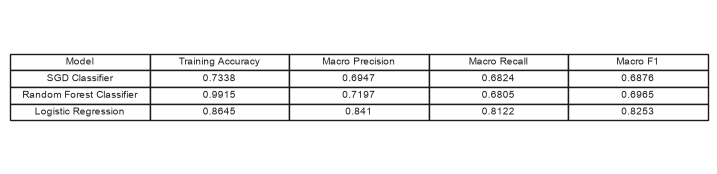

In [49]:
results = {
    "Model": ["SGD Classifier", "Random Forest Classifier", "Logistic Regression"],
    "Training Accuracy": [train_acc_sgd, train_acc_forest, train_acc_lr],
    "Macro Precision": [
        precision_score(y_train_encoded, y_pred_cv_sgd, average='macro'),
        precision_score(y_train_encoded, y_pred_cv_forest, average='macro'),
        precision_score(y_train_encoded, y_pred_cv_lr, average='macro')
    ],
    "Macro Recall": [
        recall_score(y_train_encoded, y_pred_cv_sgd, average='macro'),
        recall_score(y_train_encoded, y_pred_cv_forest, average='macro'),
        recall_score(y_train_encoded, y_pred_cv_lr, average='macro')
    ],
    "Macro F1": [
        f1_score(y_train_encoded, y_pred_cv_sgd, average='macro'),
        f1_score(y_train_encoded, y_pred_cv_forest, average='macro'),
        f1_score(y_train_encoded, y_pred_cv_lr, average='macro')
    ]
}

df_results = pd.DataFrame(results)

# Round to 4 decimal places
df_results = df_results.round(4)
print(df_results)

# Display nicely as table
fig, ax = plt.subplots(figsize=(9,2))
ax.axis('off')
ax.axis('tight')
ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    cellLoc='center',
    loc='center'
)
plt.show()


In [50]:
print("\n6. LOGISTIC REGRESSION - HYPERPARAMETER TUNING & FINAL TESTING")
print("="*70)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


6. LOGISTIC REGRESSION - HYPERPARAMETER TUNING & FINAL TESTING


In [51]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  
    'solver': ['liblinear', 'saga'] 
}

In [52]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

In [53]:
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

In [54]:
grid_search.fit(X_train_tr, y_train_encoded)

print("✓ Best Parameters:", grid_search.best_params_)
print("✓ Best CV Accuracy:", grid_search.best_score_)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "

✓ Best Parameters: {'C': 10, 'solver': 'saga'}
✓ Best CV Accuracy: 0.8505


In [55]:
best_model = grid_search.best_estimator_
best_model

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elasti

In [56]:
print('Best hyperparameter settings:', grid_search.best_params_)

Best hyperparameter settings: {'C': 10, 'solver': 'saga'}


In [57]:
# Split the test set into numerical and categorical sets
all_categorical_cols = ['employee_id','gender', 'education_level', 'job_title', 'location', 'work_mode', 
                   'primary_language', 'birth_month', 'stock_options']

X_test_num = X_test.drop(all_categorical_cols, axis=1)  # Drop categorical columns to get numerical
X_test_cat = X_test[all_categorical_cols] 

X_test_cat = X_test_cat.drop('employee_id', axis=1) 

print('X_test_num shape:', X_test_num.shape)
print('X_test_cat shape:', X_test_cat.shape)

X_test_num shape: (1000, 10)
X_test_cat shape: (1000, 8)


In [58]:
# Encode categorical test features
X_test_cat_tr = ohe.transform(X_test_cat)

# Impute and scale numerical test features
X_test_num_tr = imputer.transform(X_test_num)
X_test_num_tr = scaler.transform(X_test_num_tr)

# Combine both
X_test_tr = np.hstack([X_test_num_tr, X_test_cat_tr])

# Encode target labels
y_test_encoded = labelE.transform(y_test)


In [59]:
from sklearn.metrics import accuracy_score, confusion_matrix

best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test_tr)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test_encoded, y_pred_final))

# Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred_final)
print("Confusion Matrix:\n", cm)


Test Accuracy: 0.848
Confusion Matrix:
 [[131   0  48]
 [  0 229  40]
 [ 26  38 488]]


In [62]:
# Predict on test set
y_pred_final = best_model.predict(X_test_tr)

# Encode true labels
y_test_encoded = labelE.transform(y_test)

# Compute RMSE
final_mse = mean_squared_error(y_test_encoded, y_pred_final)
final_rmse = np.sqrt(final_mse)

print("Final RMSE:", final_rmse)


Final RMSE: 0.6115553940568262


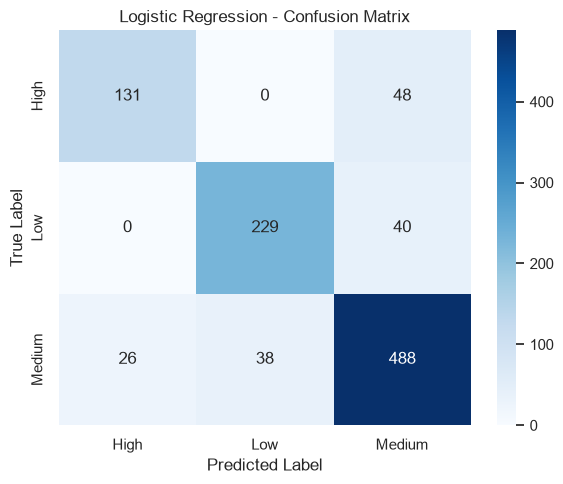

In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_final)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
